In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Loan_default.csv")

In [4]:
print(df.head())

       LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1      Full-time    

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

The current dataset contains no missing values. However, i have implemented the following cleaning pipeline to ensure the model can handle missing data in future production environments: Numeircal values are imputed with the median and categorical values are imputed with the mode

In [6]:
# Handling Numerical Columns
num_cols = df.select_dtypes(include = ['number']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [7]:
# Handling Categorical Columns
cat_cols = df.select_dtypes(include = ['object']).columns
for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
print(df.isnull().sum())

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [9]:
print("duplicates before:", df.duplicated().sum())

duplicates before: 0


In [10]:
# Even though the initial dataset has 0 duplicates, i have included this to ensure the pipeline remains robust if the data source is updated
initial_duplicates = df.duplicated().sum()
print("duplicates identified: {initial_duplicates}")

if initial_duplicates > 0:
    df = df.drop_duplicates()
    print("duplicates removed successfully.")

duplicates identified: {initial_duplicates}


In [11]:
cols_to_category = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
cols_to_numeric = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

In [12]:
for col in cols_to_category:
    df[col] = df[col].astype('category')

for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

print("Full data pipeline executed. All types are now optimized.")

Full data pipeline executed. All types are now optimized.


In [13]:
print(df.dtypes)

LoanID              object
Age                  int64
Income               int64
LoanAmount           int64
CreditScore          int64
MonthsEmployed       int64
NumCreditLines       int64
InterestRate       float64
LoanTerm             int64
DTIRatio           float64
Education         category
EmploymentType    category
MaritalStatus     category
HasMortgage       category
HasDependents     category
LoanPurpose       category
HasCoSigner       category
Default              int64
dtype: object


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
cols_to_check = ['Income', 'NumCreditLines', 'LoanAmount', 'DTIRatio', 'MonthsEmployed', 'InterestRate']

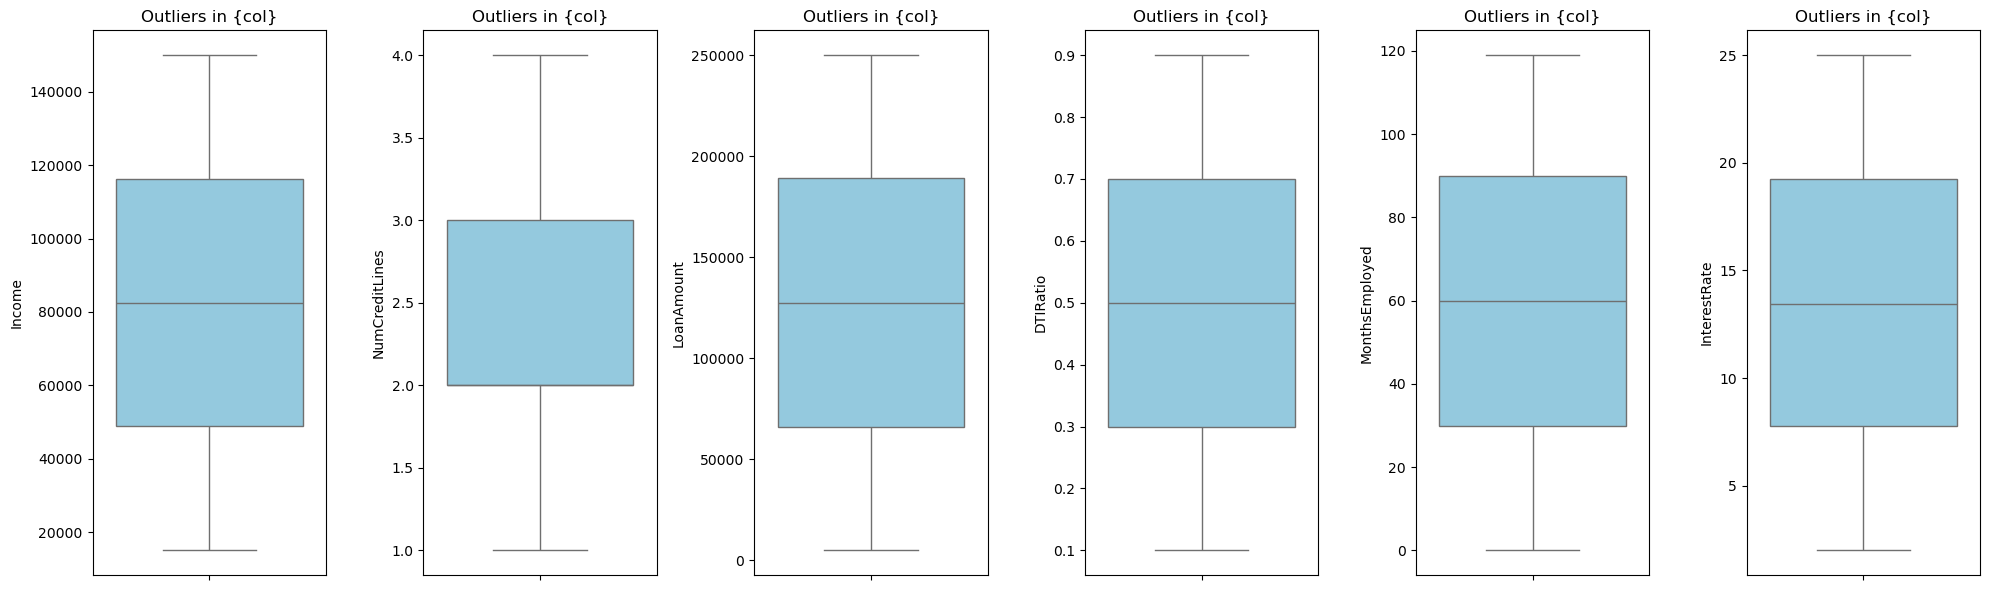

In [16]:
plt.figure(figsize = (20, 6))
for i, col in enumerate(cols_to_check):
    plt.subplot(1, 6, i+1)
    sns.boxplot(y = df[col], color = 'skyblue')
    plt.title('Outliers in {col}')

plt.tight_layout()
plt.show()

In [17]:
import re
df.columns = [re.sub('(?<!^)(?=[A-Z])', '_', col).lower().replace('loan_i_d', 'loan_id').replace('d_t_i', 'dti') for col in df.columns]
print(df.columns)

Index(['loan_id', 'age', 'income', 'loan_amount', 'credit_score',
       'months_employed', 'num_credit_lines', 'interest_rate', 'loan_term',
       'dti_ratio', 'education', 'employment_type', 'marital_status',
       'has_mortgage', 'has_dependents', 'loan_purpose', 'has_co_signer',
       'default'],
      dtype='object')


In [18]:
binary_cols = ['has_mortgage', 'has_dependents', 'has_co_signer']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df = pd.get_dummies(df, columns = ['employment_type', 'marital_status', 'loan_purpose'], drop_first = True)

edu_map = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
df['education'] = df['education'].map(edu_map)

In [19]:
# Income to Loan Ratio
df['income_loan_ratio'] = df['income'] / df['loan_amount']

# Credit Utilization Proxy
df['credit_density'] = df['num_credit_lines'] / (df['age'] - 17).clip(lower = 1)

# Employment Stability
df['employment_stability'] = df['months_employed'] / (df['age'] * 12)

# Monthly Interest Burden
df['estimated_monthly_interest'] = (df['loan_amount'] * (df['interest_rate']/100)) / 12

In [20]:
print(df.head())

      loan_id  age  income  loan_amount  credit_score  months_employed  \
0  I38PQUQS96   56   85994        50587           520               80   
1  HPSK72WA7R   69   50432       124440           458               15   
2  C1OZ6DPJ8Y   46   84208       129188           451               26   
3  V2KKSFM3UN   32   31713        44799           743                0   
4  EY08JDHTZP   60   20437         9139           633                8   

   num_credit_lines  interest_rate  loan_term  dti_ratio  ...  \
0                 4          15.23         36       0.44  ...   
1                 1           4.81         60       0.68  ...   
2                 3          21.17         24       0.31  ...   
3                 3           7.07         24       0.23  ...   
4                 4           6.51         48       0.73  ...   

  marital_status_Married marital_status_Single loan_purpose_Business  \
0                  False                 False                 False   
1                   

In [21]:
file_name = 'Credit_Data.csv'
df.to_csv(file_name, index = False)